In [ ]:

# **************************************************
# Module : COM 763
# Network Intrusion Detection using Machine Learning
# Author: Palitha Kuruvita / 25026175
# ***************************************************



# Module 1: Loading Dataset
# ************************************************


import pandas as pnd
import numpy as nmp
import os

# Configuration of Constants
DATA_FILENAME = "data.csv"
TARGET_COLUMN_NAME = " Label"

print("=" * 70)
print(f"Module 1: Initiating Dataset")
print("=" * 70)

print(f"Loading the dataset: '{DATA_FILENAME}'")

# Check : dataset file exists or not
if not os.path.exists(DATA_FILENAME):
    raise FileNotFoundError(
        f"Dataset '{DATA_FILENAME}' is not available. Please verify."
    )

# Loading dataset in pandas DataFrame
first_network_dtf = pnd.read_csv(DATA_FILENAME)

print("Dataset loaded successfully into 'first_network_dtf'.")

# Display Basic Dataset Information

print("\n" + "=" * 70)
print("Dataset Dimensions (Rows, Columns)")
print("=" * 70)
print(f"Number of Rows    : {first_network_dtf.shape[0]}")
print(f"Number of Columns : {first_network_dtf.shape[1]}")

print("\n" + "=" * 70)
print("First 5 Rows of the Dataset (Head)")
print("=" * 70)
print(first_network_dtf.head())

print("\n" + "=" * 70)
print("Detailed Dataset Information (Info)")
print("=" * 70)
first_network_dtf.info()

print("\n" + "=" * 70)
print("Statistical Summary of Numerical Features (Describe)")
print("=" * 70)
print(first_network_dtf.describe())

print("\n" + "=" * 70)
print("Data Types Per Column")
print("=" * 70)
print(first_network_dtf.dtypes)

print("\n" + "=" * 70)
print("Missing Values Count Per Column")
print("=" * 70)
first_missing_values = first_network_dtf.isnull().sum()
print(first_missing_values)
print(f"\nTotal Missing Values Across All Columns: {first_missing_values.sum()}")

print("\n" + "=" * 70)
print("Duplicate Row Count")
print("=" * 70)
initial_duplicate_rows = first_network_dtf.duplicated().sum()
print(f"Number of Duplicate Rows: {initial_duplicate_rows}")

print("\n" + "=" * 70)
print(f"Target Class Distribution (Column: '{TARGET_COLUMN_NAME}')")
print("=" * 70)
if TARGET_COLUMN_NAME in first_network_dtf.columns:
    print(first_network_dtf[TARGET_COLUMN_NAME].value_counts())
else:
    print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found in the dataset.")
    print("Please update 'TARGET_COLUMN_NAME' to match dataset's actual target column.")

print("\n" + "=" * 70)
print("Dataset Memory Usage")
print("=" * 70)
first_memory_usage_mb = first_network_dtf.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory Used: {first_memory_usage_mb:.2f} MB")

print("\n" + "=" * 70)
print("Unique Values Count Per Column")
print("=" * 70)
print(first_network_dtf.nunique())

print("\n" + "=" * 70)
print("Module 1: Dataset Loading Completed")
print("=" * 70)


Module 1: Initiating Dataset
Loading the dataset: 'data.csv'
Dataset loaded successfully into 'first_network_dtf'.

Dataset Dimensions (Rows, Columns)
Number of Rows    : 65758
Number of Columns : 79

First 5 Rows of the Dataset (Head)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Len

In [10]:
# Module 2 : Data Cleaning
# *************************


import pandas as pnd
import numpy as nmp

print("=" * 70)
print("Module 2: Initiating Data Cleaning")
print("=" * 70)

# Configuration Constants (consistent with Module 1)
# DATA_FILENAME = "data.csv" # Already defined in Module 1
# TARGET_COLUMN_NAME = " Label" # Already defined in Module 1

print(f"Re-loading dataset '{DATA_FILENAME}' for cleaning operations.")
uncleaned_data_df = pnd.read_csv(DATA_FILENAME)

print("Original dataset loaded into 'uncleaned_data_df'.")
print(f"Initial Shape (rows, columns): {uncleaned_data_df.shape}")

# Identify the target column
actual_target_column = None
for col in uncleaned_data_df.columns:
    if col.strip() == TARGET_COLUMN_NAME.strip():
        actual_target_column = col
        break

if actual_target_column is None:
    print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found. Please verify.")
else:
    print(f"\nTarget Class Distribution (before cleaning) for '{actual_target_column}':")
    print(uncleaned_data_df[actual_target_column].value_counts())
    print("\n")

# Remove Duplicate Records
print("Step 1: Removing duplicate rows")
initial_row_count = uncleaned_data_df.shape[0]
preprocessed_data_df = uncleaned_data_df.drop_duplicates().copy() # Added .copy() to prevent SettingWithCopyWarning
num_rows_removed_duplicates = initial_row_count - preprocessed_data_df.shape[0]
print(f"Number of rows removed due to duplication: {num_rows_removed_duplicates}")
print(f"Shape after duplicate removal: {preprocessed_data_df.shape}")

# Handle Missing and Infinite Values
print("\nStep 2: Handling infinite and missing values")
# Replace infinite values with NaN
preprocessed_data_df.replace([nmp.inf, -nmp.inf], nmp.nan, inplace=True)
# Drop rows containing any NaN values
row_count_before_nan_inf = preprocessed_data_df.shape[0]
preprocessed_data_df.dropna(inplace=True)
num_rows_removed_nan_inf = row_count_before_nan_inf - preprocessed_data_df.shape[0]
print(f"Number of rows removed due to missing/infinite values: {num_rows_removed_nan_inf}")
print(f"Shape after handling missing and infinite values: {preprocessed_data_df.shape}")

# Convert Columns to Numeric Types
print("\nStep 3: Convert all applicable columns to numeric types...")
for col_name in preprocessed_data_df.columns:
    try:
        preprocessed_data_df[col_name] = pnd.to_numeric(preprocessed_data_df[col_name])
    except ValueError:
        # Failure means it's likely a non-numeric column (like the target label)
        pass
print("Numeric conversion process completed.")

# Check class distribution before outlier removal
if actual_target_column is not None:
    print("\n" + "=" * 70)
    print(f"Target Class Distribution (BEFORE Outlier Removal) for '{actual_target_column}'")
    print("=" * 70)
    print(preprocessed_data_df[actual_target_column].value_counts())
    print("\n")

# Outlier Removal using Interquartile Range (IQR) ---
print("Step 4: Removing Outliers using IQR for numerical features")

numeric_columns = preprocessed_data_df.select_dtypes(include=nmp.number).columns

row_count_before_outlier = preprocessed_data_df.shape[0]

for col_name_for_outlier in numeric_columns:
    Q1 = preprocessed_data_df[col_name_for_outlier].quantile(0.25)
    Q3 = preprocessed_data_df[col_name_for_outlier].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    preprocessed_data_df = preprocessed_data_df[
        (preprocessed_data_df[col_name_for_outlier] >= lower_bound) &
        (preprocessed_data_df[col_name_for_outlier] <= upper_bound)
    ]

final_row_count_after_outlier = preprocessed_data_df.shape[0]
num_rows_removed_outlier = row_count_before_outlier - final_row_count_after_outlier

print(f"Rows Before Outlier Removal : {row_count_before_outlier}")
print(f"Rows After Outlier Removal  : {final_row_count_after_outlier}")
print(f"Total Rows Removed by Outlier Removal: {num_rows_removed_outlier}")

# Check class distribution after outlier removal
if actual_target_column is not None:
    print("\n" + "=" * 70)
    print(f"Target Class Distribution (AFTER Outlier Removal) for '{actual_target_column}'")
    print("=" * 70)
    print(preprocessed_data_df[actual_target_column].value_counts())
    print("\n")

# Reset DataFrame Index
print("Step 5: Resetting DataFrame index...")
preprocessed_data_df.reset_index(drop=True, inplace=True)
print("Data cleaning and preprocessing steps completed.")

print("\n" + "=" * 70)
print("Module 2: Data Cleaning and Preprocessing Completed")
print("=" * 70)

# The `preprocessed_data_df` variable now holds the cleaned data for subsequent modules.


Module 2: Initiating Data Cleaning
Re-loading dataset 'data.csv' for cleaning operations.
Original dataset loaded into 'uncleaned_data_df'.
Initial Shape (rows, columns): (65758, 79)

Target Class Distribution (before cleaning) for ' Label':
 Label
DDoS      34468
BENIGN    31290
Name: count, dtype: int64


Step 1: Removing duplicate rows
Number of rows removed due to duplication: 530
Shape after duplicate removal: (65228, 79)

Step 2: Handling infinite and missing values
Number of rows removed due to missing/infinite values: 15
Shape after handling missing and infinite values: (65213, 79)

Step 3: Convert all applicable columns to numeric types...
Numeric conversion process completed.

Target Class Distribution (BEFORE Outlier Removal) for ' Label'
 Label
DDoS      34466
BENIGN    30747
Name: count, dtype: int64


Step 4: Removing Outliers using IQR for numerical features
Rows Before Outlier Removal : 65213
Rows After Outlier Removal  : 4784
Total Rows Removed by Outlier Removal: 6042

Module 3: Initiating Exploratory Data Analysis (EDA)
Loading dataset 'data.csv' for EDA.
Dataset loaded successfully into 'exploration_df'.
Initial shape: (65758, 79)

Preprocessing for EDA: Handling infinite values and missing data
Shape after replacing infinite values and dropping NaNs: (65743, 79)

Detailed Dataset Information (after EDA-specific cleaning)
<class 'pandas.core.frame.DataFrame'>
Index: 65743 entries, 0 to 65757
Data columns (total 79 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0    Destination Port             65743 non-null  int64  
 1    Flow Duration                65743 non-null  int64  
 2    Total Fwd Packets            65743 non-null  int64  
 3    Total Backward Packets       65743 non-null  int64  
 4   Total Length of Fwd Packets   65743 non-null  int64  
 5    Total Length of Bwd Packets  65743 non-null  int64  
 6    Fwd Packet Length Max        65743 non-null  int64  
 7 

/tmp/ipykernel_2701/2656801388.py:55: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  mplt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout and make space for suptitle


<Figure size 2000x1800 with 0 Axes>

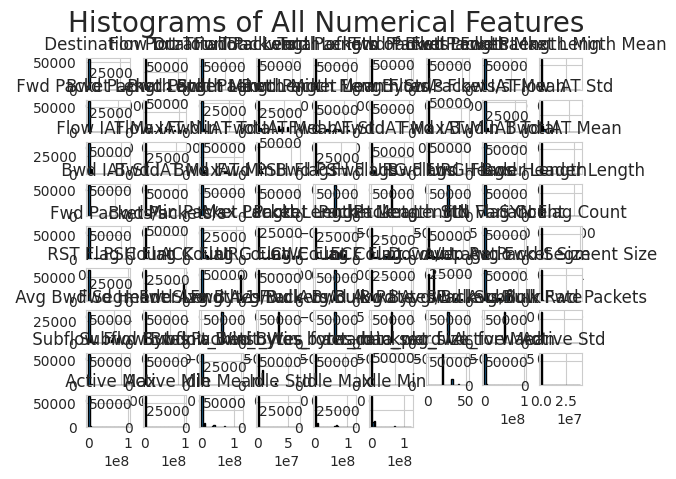

Histograms generated and saved as 'Histogram_All_Features.png'.

Generating Correlation Heatmap for numerical features to identify relationships...


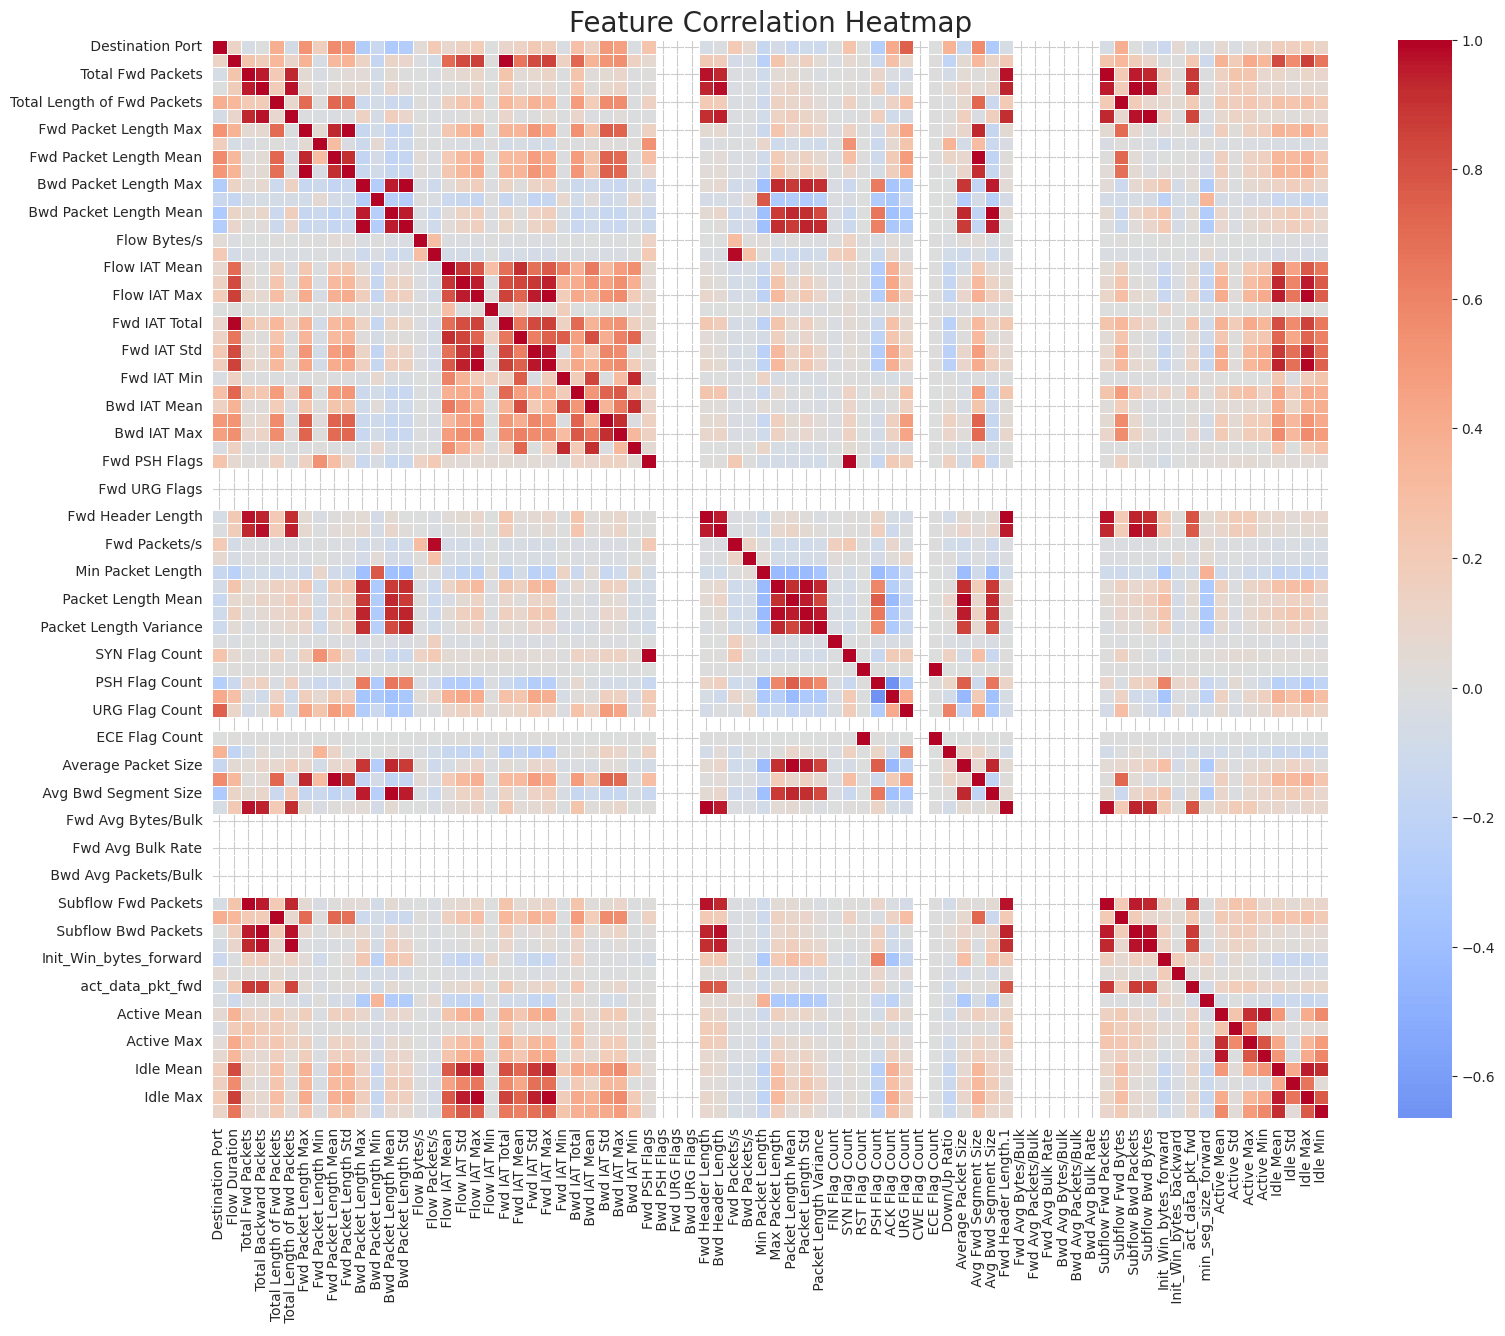

Correlation Heatmap generated and saved as 'Correlation_Heatmap.png'.

Generating Boxplots for the top 10 numerical features to visualize outliers


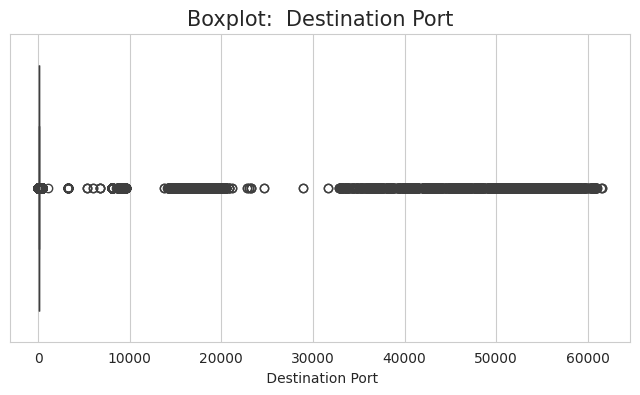

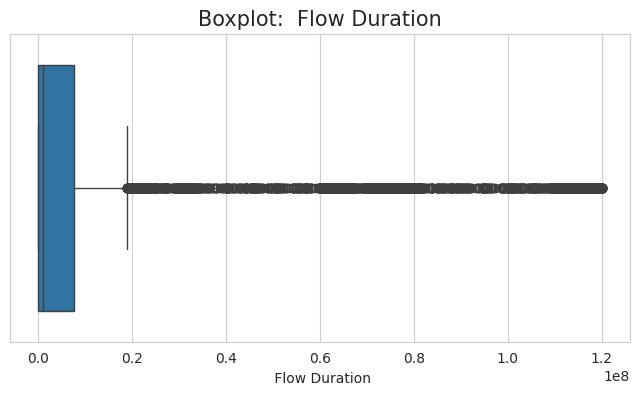

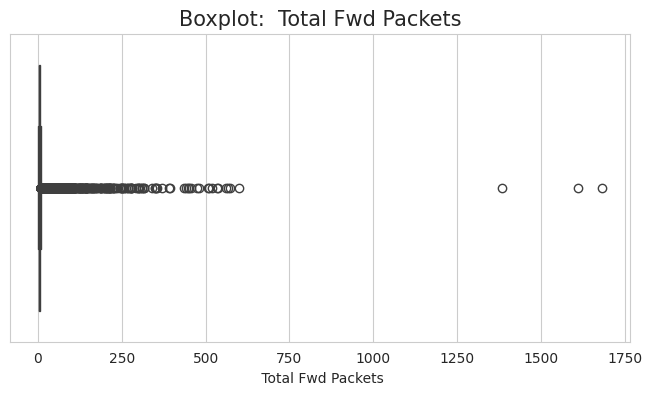

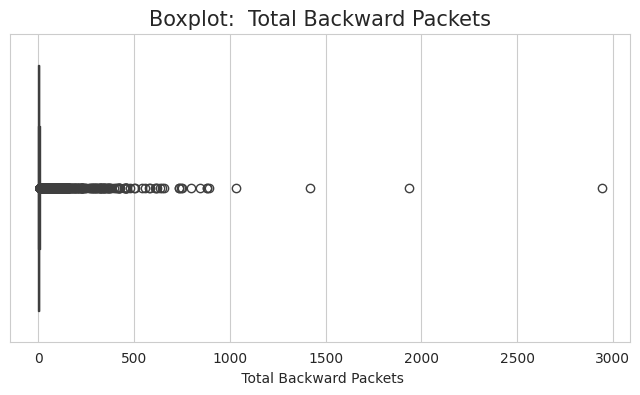

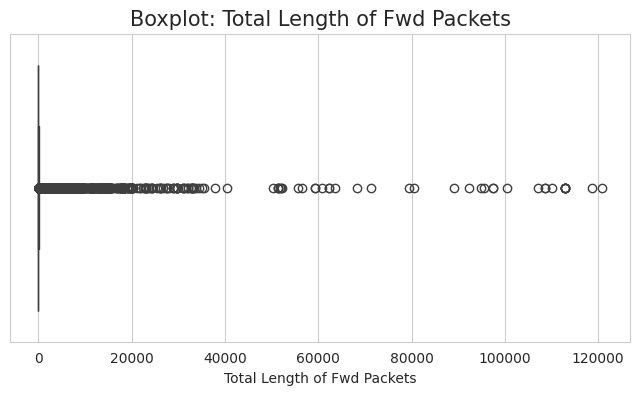

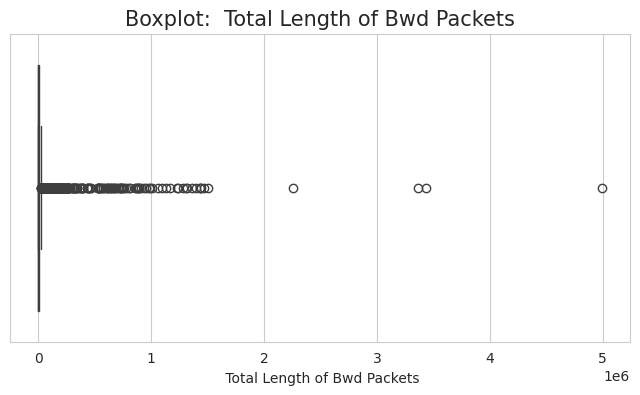

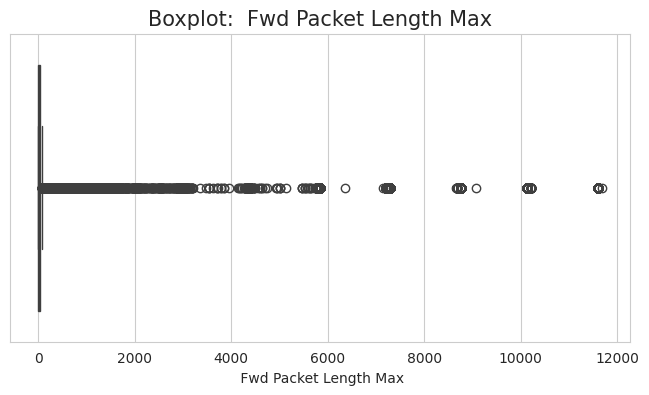

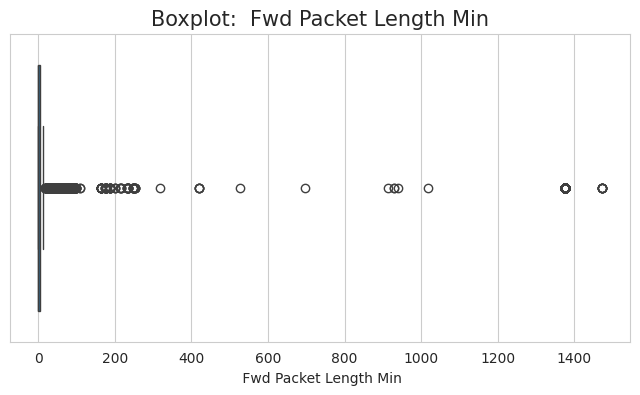

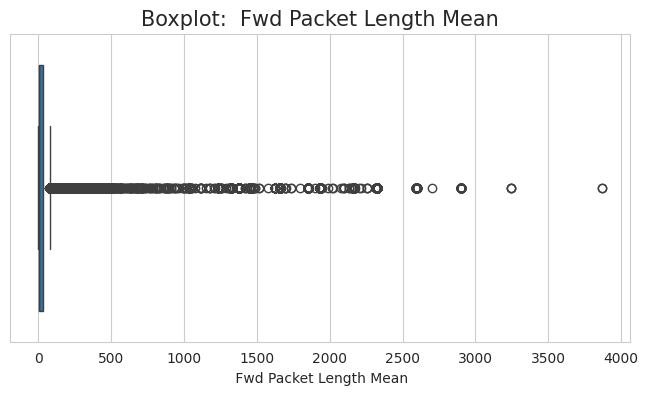

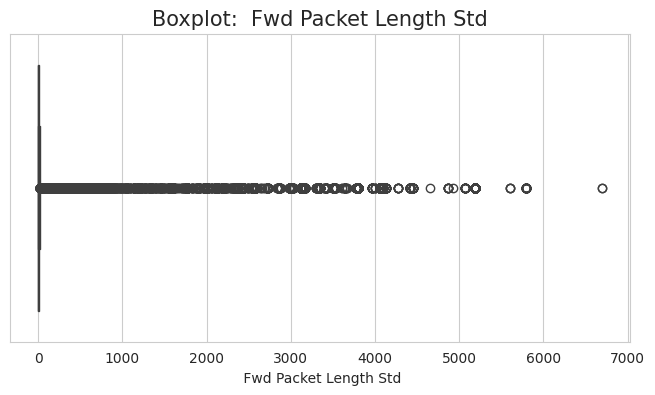

Boxplots for top numerical features generated.

Analyzing distribution of the target variable: ' Label'...


/tmp/ipykernel_2701/2656801388.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.countplot(


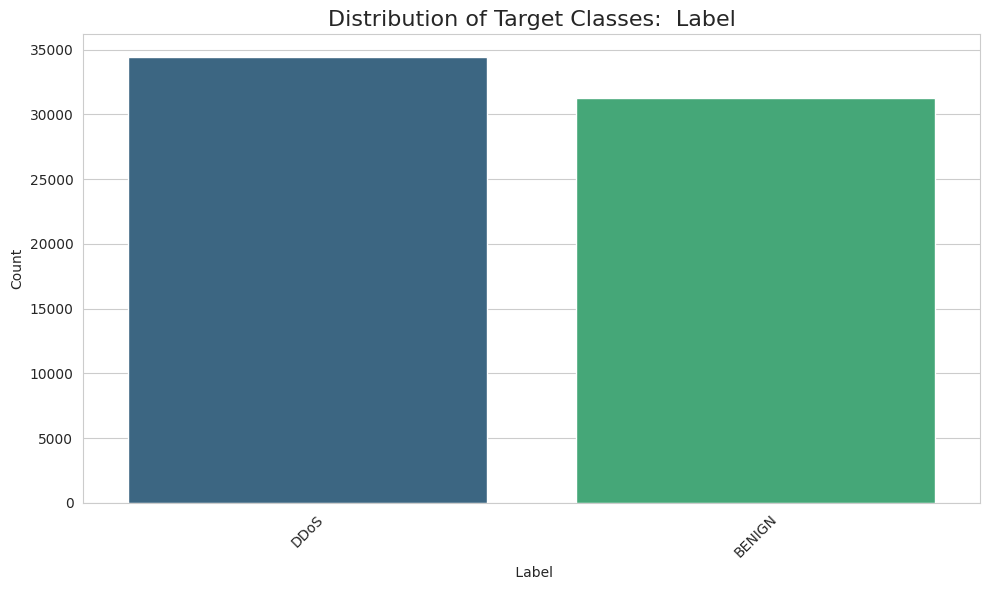

Target class distribution plot generated and saved as 'Class_Distribution.png'.

Generating Missing Values Heatmap to confirm no NaNs remain


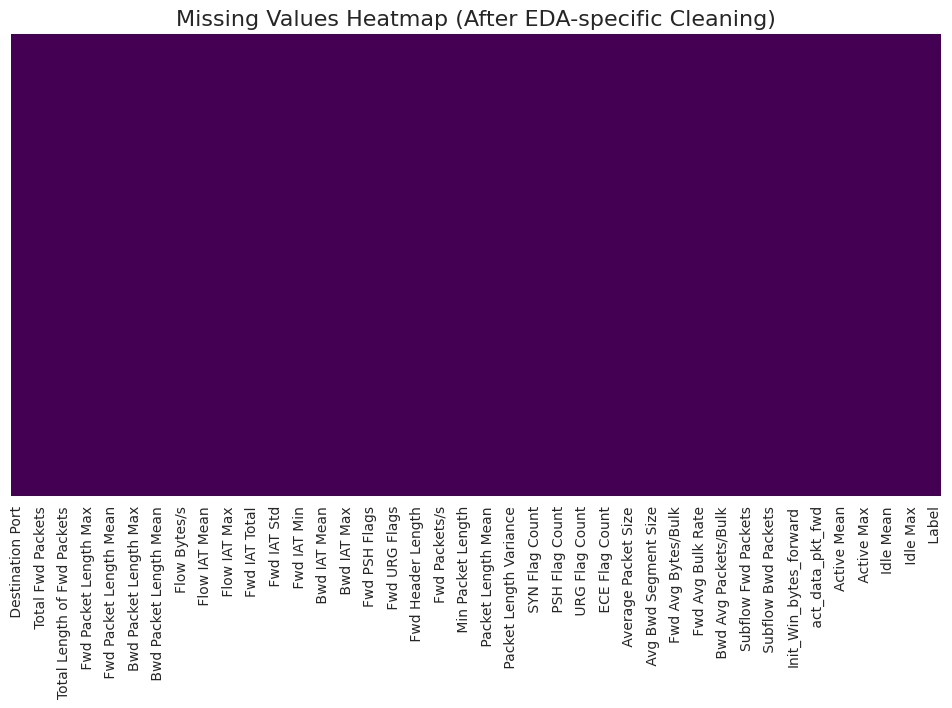

Missing Values Heatmap generated and saved as 'Missing_Values.png'.

Generating Density Plots for the top 6 numerical features to show value distribution...


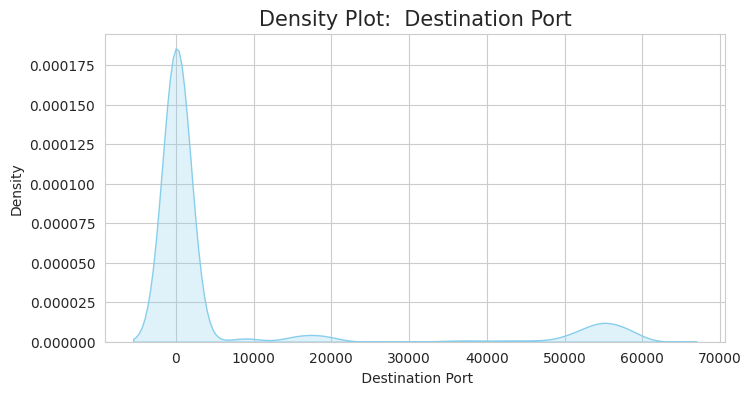

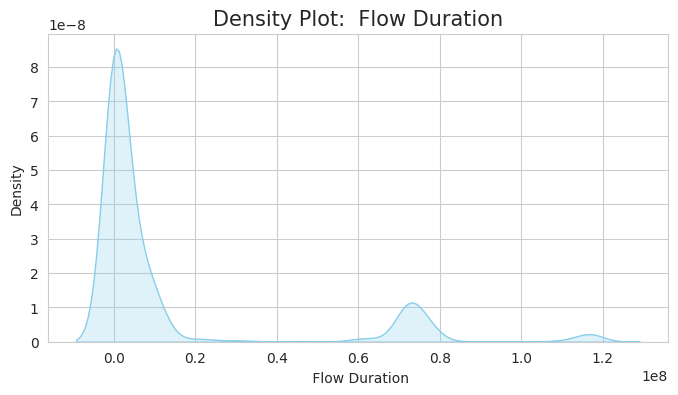

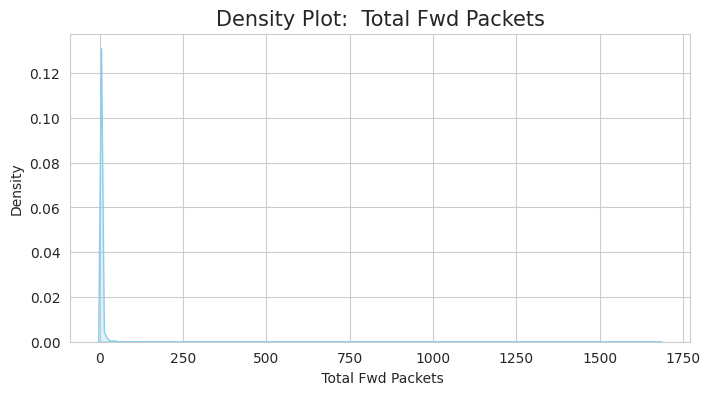

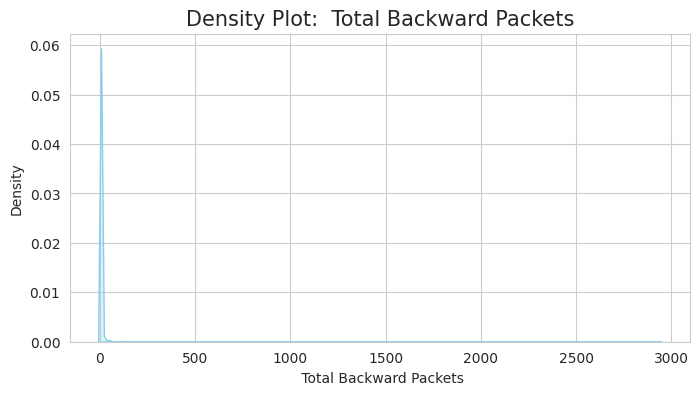

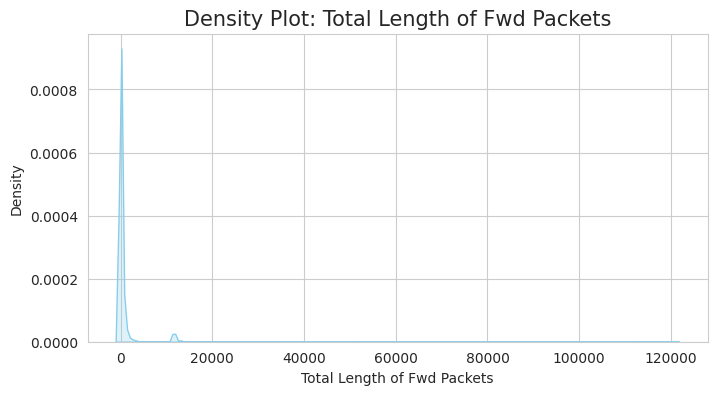

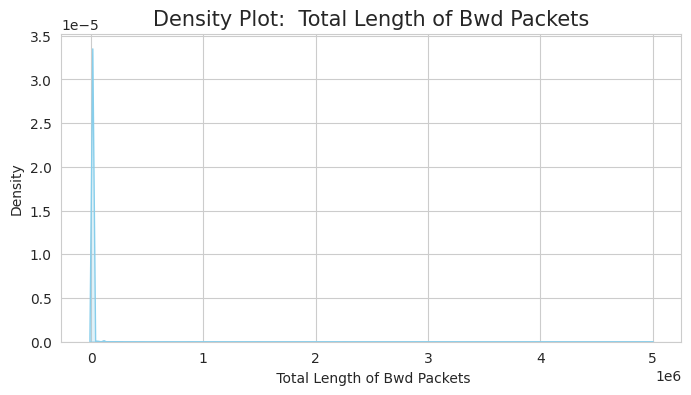

Density plots for top numerical features generated.

Generating Pair Plot for a sample of data to visualize relationships


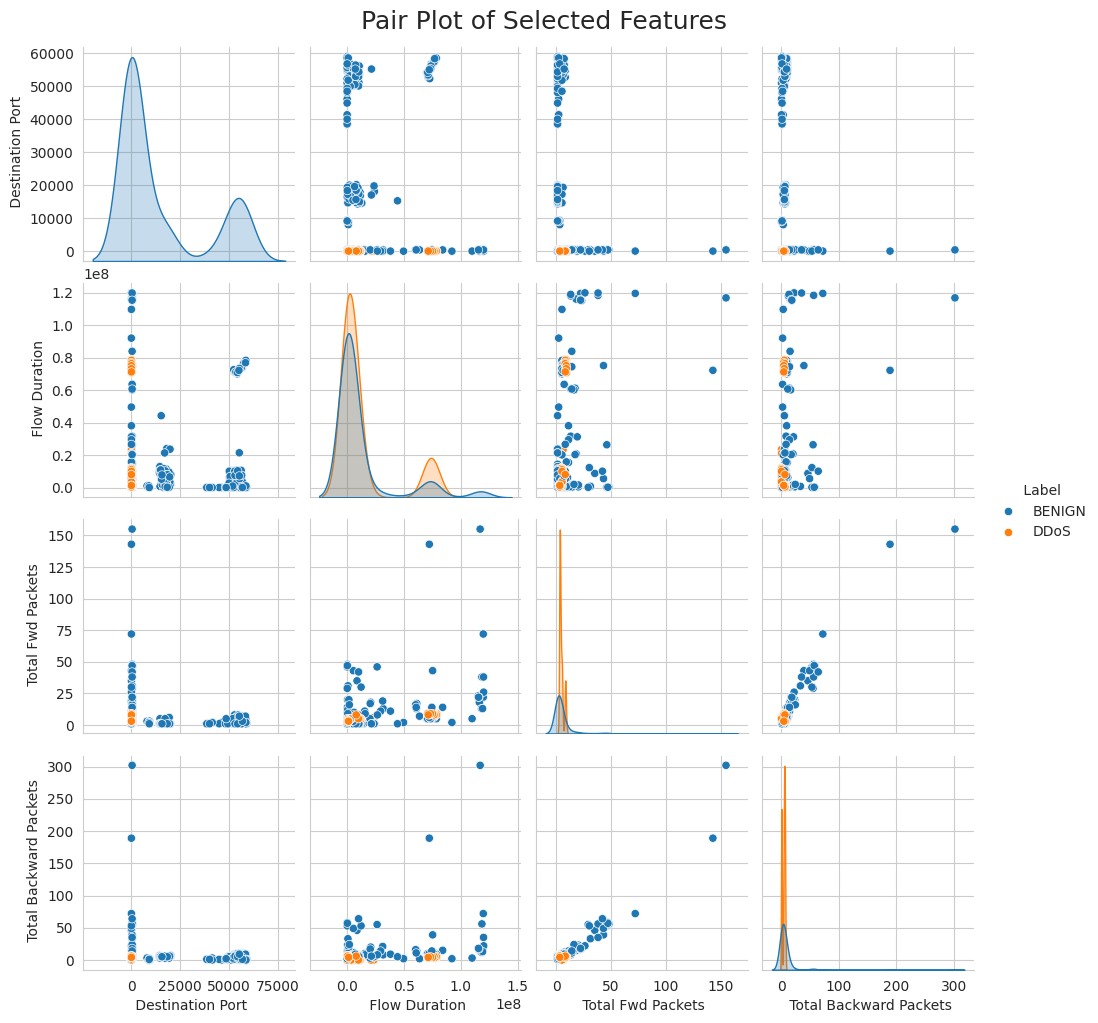

Pair Plot generated and saved as 'PairPlot.png'.

Saving the calculated Correlation Matrix to 'Correlation_Matrix.csv'
Correlation Matrix saved successfully.

Module 3: Exploratory Data Analysis (EDA) Completed


In [12]:
# Module 3: Exploratory Data Analysis (EDA)
# ******************************************

# Load necessary libraries
import pandas as pnd
import matplotlib.pyplot as mplt
import seaborn as sbn
import numpy as nmp

sbn.set_style("whitegrid") # Set a consistent visual style for plots

print("=" * 70)
print("Module 3: Initiating Exploratory Data Analysis (EDA)")
print("=" * 70)

# Configuration Constants (consistent with Module 1) ---
# DATA_FILENAME = "data.csv" # Already defined in Module 1
# TARGET_COLUMN_NAME = " Label" # Already defined in Module 1

print(f"Loading dataset '{DATA_FILENAME}' for EDA.")
exploration_df = pnd.read_csv(DATA_FILENAME)

print("Dataset loaded successfully into 'exploration_df'.")
print(f"Initial shape: {exploration_df.shape}")

# Handle infinite values and NaNs
print("\nPreprocessing for EDA: Handling infinite values and missing data")
exploration_df.replace([nmp.inf, -nmp.inf], nmp.nan, inplace=True)
exploration_df.dropna(inplace=True)
print(f"Shape after replacing infinite values and dropping NaNs: {exploration_df.shape}")

# Display Basic Dataset Information
print("\n" + "=" * 70)
print("Detailed Dataset Information (after EDA-specific cleaning)")
print("=" * 70)
exploration_df.info()

print("\n" + "=" * 70)
print("Statistical Summary of Numerical Features (after EDA-specific cleaning)")
print("=" * 70)
print(exploration_df.describe())

# Visualizations for Data Distribution

# Histograms for Numerical Features
print("\nGenerating Histograms for all numerical features to visualize distributions")
numeric_features_eda = exploration_df.select_dtypes(include=nmp.number).columns

mplt.figure(figsize=(20,18))
exploration_df[numeric_features_eda].hist(
    bins=30,
    edgecolor='black'
)

mplt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout and make space for suptitle
mplt.suptitle("Histograms of All Numerical Features", fontsize=20) # Add a main title
mplt.savefig("Histogram_All_Features.png") # Save the plot
mplt.show() # Display the plot
print("Histograms generated and saved as 'Histogram_All_Features.png'.")

# 2. Correlation Heatmap
print("\nGenerating Correlation Heatmap for numerical features to identify relationships...")
feature_correlation_matrix = exploration_df.corr(numeric_only=True) # Calculate correlation matrix

mplt.figure(figsize=(18,14))
sbn.heatmap(
    feature_correlation_matrix,
    cmap="coolwarm", # Color map for positive and negative correlations
    center=0,        # Center the color map at 0
    linewidths=.5,   # Add lines between cells
    linecolor='white',
    fmt=".2f" # Format annotations to 2 decimal places
)

mplt.title("Feature Correlation Heatmap", fontsize=20) # Add title
mplt.savefig("Correlation_Heatmap.png") # Save the plot
mplt.show() # Display the plot
print("Correlation Heatmap generated and saved as 'Correlation_Heatmap.png'.")

#*Boxplots for Outlier Detection
print("\nGenerating Boxplots for the top 10 numerical features to visualize outliers")
# Select the first 10 numerical features for boxplots (adjust as needed)
top_features_for_boxplot = numeric_features_eda[:10]

for current_feature in top_features_for_boxplot:
    mplt.figure(figsize=(8,4))
    sbn.boxplot(x=exploration_df[current_feature]) # Create a boxplot
    mplt.title(f"Boxplot: {current_feature}", fontsize=15)
    mplt.xlabel(current_feature) # Add x-axis label
    mplt.savefig(f"Boxplot_{current_feature.strip()}.png") # Save plot (strip space from name for file)
    mplt.show() # Display the plot
print("Boxplots for top numerical features generated.")

# Target Class Distribution
print(f"\nAnalyzing distribution of the target variable: '{TARGET_COLUMN_NAME}'...")

if TARGET_COLUMN_NAME in exploration_df.columns:
    mplt.figure(figsize=(10,6))
    sbn.countplot(
        x=exploration_df[TARGET_COLUMN_NAME],
        order=exploration_df[TARGET_COLUMN_NAME].value_counts().index,
        palette='viridis'
    )
    mplt.xticks(rotation=45) # Rotate labels if they overlap
    mplt.title(f"Distribution of Target Classes: {TARGET_COLUMN_NAME}", fontsize=16)
    mplt.xlabel(TARGET_COLUMN_NAME)
    mplt.ylabel("Count")
    mplt.tight_layout()
    mplt.savefig("Class_Distribution.png")
    mplt.show()
    print(f"Target class distribution plot generated and saved as 'Class_Distribution.png'.")
else:
    print(f"Target column '{TARGET_COLUMN_NAME}' not found for class distribution analysis.")

# Missing Values Heatmap (re-checking after dropna)
print("\nGenerating Missing Values Heatmap to confirm no NaNs remain")

mplt.figure(figsize=(12,6))
sbn.heatmap(
    exploration_df.isnull(), # Check for any remaining nulls
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)
mplt.title("Missing Values Heatmap (After EDA-specific Cleaning)", fontsize=16)
mplt.savefig("Missing_Values.png")
mplt.show()
print("Missing Values Heatmap generated and saved as 'Missing_Values.png'.")

# Feature Density Plots
print("\nGenerating Density Plots for the top 6 numerical features to show value distribution...")
top_features_for_density_plot = numeric_features_eda[:6]

for current_feature in top_features_for_density_plot:
    mplt.figure(figsize=(8,4))
    sbn.kdeplot(exploration_df[current_feature], fill=True, color='skyblue') # Create a Kernel Density Estimate plot
    mplt.title(f"Density Plot: {current_feature}", fontsize=15)
    mplt.xlabel(current_feature)
    mplt.ylabel("Density")
    mplt.savefig(f"Density_{current_feature.strip()}.png")
    mplt.show()
print("Density plots for top numerical features generated.")

# Pair Plot for relationships between features
print("\nGenerating Pair Plot for a sample of data to visualize relationships")

# Sample of 1000 rows for performance reasons
eda_sampled_data = exploration_df.sample(
    n=min(1000, len(exploration_df)),
    random_state=42
)

# Select first 4 numerical features for pair plot
pairplot_features = list(numeric_features_eda[:4])
if TARGET_COLUMN_NAME in exploration_df.columns:
    pairplot_features.append(TARGET_COLUMN_NAME)

# Generate the pair plot
sbn.pairplot(
    eda_sampled_data[pairplot_features],
    hue=TARGET_COLUMN_NAME if TARGET_COLUMN_NAME in eda_sampled_data.columns else None,
    diag_kind='kde' # Use KDE for diagonal plots
)

mplt.suptitle("Pair Plot of Selected Features", y=1.02, fontsize=18) # Add a main title
mplt.savefig("PairPlot.png")
mplt.show()
print("Pair Plot generated and saved as 'PairPlot.png'.")

# Save Correlation Matrix to CSV
print("\nSaving the calculated Correlation Matrix to 'Correlation_Matrix.csv'")
feature_correlation_matrix.to_csv("Correlation_Matrix.csv", index=True)
print("Correlation Matrix saved successfully.")

print("\n" + "=" * 70)
print("Module 3: Exploratory Data Analysis (EDA) Completed")
print("=" * 70)


In [13]:
# Module 4: Train Machine Learning Models
# ***************************************

import pandas as pnd
import numpy as nmp
import warnings

warnings.filterwarnings("ignore") # Suppress warnings for cleaner output

# Machine Learning Libraries for Model Training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

print("=" * 70)
print("Module 4: Initiating Machine Learning Model Training")
print("=" * 70)

# Configuration Constants (consistent with Module 1)
# DATA_FILENAME = "data.csv" # Already defined in Module 1
# TARGET_COLUMN_NAME = " Label" # Already defined in Module 1

print(f"Loading dataset '{DATA_FILENAME}' for model training.")
raw_training_df = pnd.read_csv(DATA_FILENAME)

print(f"Initial shape of the loaded dataset: {raw_training_df.shape}")

# Handle infinite values and NaNs before model training
print("\nPreprocessing for training: Handling infinite values and missing data...")
raw_training_df.replace([nmp.inf, -nmp.inf], nmp.nan, inplace=True)
raw_training_df.dropna(inplace=True)
print(f"Shape after replacing infinite values and dropping NaNs: {raw_training_df.shape}")

# Separate features (X) and target (y)
print(f"\nSeparating features (X) and target variable (y = '{TARGET_COLUMN_NAME}')...")

# Ensure TARGET_COLUMN_NAME is present before dropping it from features
found_target_col = False
actual_target_column_name = TARGET_COLUMN_NAME # Default to global constant
for col_name in raw_training_df.columns:
    if col_name.strip() == TARGET_COLUMN_NAME.strip():
        actual_target_column_name = col_name # Use the actual column name
        found_target_col = True
        break

if not found_target_col:
    raise ValueError(f"Target column '{TARGET_COLUMN_NAME}' not found in the dataset after cleaning.")

feature_matrix_X = raw_training_df.drop(actual_target_column_name, axis=1)
target_vector_y = raw_training_df[actual_target_column_name]

# Encode Target Labels: Convert categorical labels to numerical representation
print("Encoding target labels using LabelEncoder...")
target_label_encoder = LabelEncoder()
encoded_target_vector_y = target_label_encoder.fit_transform(target_vector_y)
print("Target labels encoded successfully.")

# Split the dataset into training and testing sets
print("\nSplitting data into training (80%) and testing (20%) sets...")
X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix_X,
    encoded_target_vector_y,
    test_size=0.20,
    random_state=42,
    stratify=encoded_target_vector_y # Stratify to maintain class distribution
)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples:  {X_test.shape[0]}")

# Feature Scaling: Standardize numerical features for models sensitive to scale
print("\nApplying feature scaling using StandardScaler to training and test sets")
data_scaler_obj = StandardScaler()
X_train_scaled = data_scaler_obj.fit_transform(X_train)
X_test_scaled = data_scaler_obj.transform(X_test)
print("Features scaled successfully. Scaled data stored in X_train_scaled and X_test_scaled.")

# Define the machine learning models to be trained
classifier_models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":
        DecisionTreeClassifier(random_state=42),
    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
    "KNN":
        KNeighborsClassifier(),
    "Support Vector Machine":
        SVC(random_state=42, probability=True),
    "Neural Network":
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=300,
            random_state=42,
            early_stopping=True # Add early stopping to prevent overfitting
        )
}

# Train each defined machine learning model
trained_classifiers = {}

print("\nStarting Model Training Process for all defined classifiers...\n")

for current_model_name, current_model_instance in classifier_models.items():
    print(f"Training {current_model_name}...")

    # Determine if the model requires scaled features for training
    if current_model_name in [
        "Logistic Regression",
        "KNN",
        "Support Vector Machine",
        "Neural Network"
    ]:
        current_model_instance.fit(X_train_scaled, y_train)
    else:
        current_model_instance.fit(X_train, y_train)
    trained_classifiers[current_model_name] = current_model_instance

    print(f"{current_model_name} Training Completed.\n")

print("=" * 70)
print("All Machine Learning Models Trained Successfully")
print("=" * 70)

# Store the fitted StandardScaler object for later use (e.g., in Streamlit app)
fitted_data_scaler = data_scaler_obj

Module 4: Initiating Machine Learning Model Training
Loading dataset 'data.csv' for model training.
Initial shape of the loaded dataset: (65758, 79)

Preprocessing for training: Handling infinite values and missing data...
Shape after replacing infinite values and dropping NaNs: (65743, 79)

Separating features (X) and target variable (y = ' Label')...
Encoding target labels using LabelEncoder...
Target labels encoded successfully.

Splitting data into training (80%) and testing (20%) sets...
Training Samples: 52594
Testing Samples:  13149

Applying feature scaling using StandardScaler to training and test sets
Features scaled successfully. Scaled data stored in X_train_scaled and X_test_scaled.

Starting Model Training Process for all defined classifiers...

Training Logistic Regression...
Logistic Regression Training Completed.

Training Decision Tree...
Decision Tree Training Completed.

Training Random Forest...
Random Forest Training Completed.

Training Extra Trees...
Extra Trees

In [14]:
# Module 5: Evaluate Machine Learning Models
# *******************************************

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

print("=" * 70)
print("Module 5: Initiating Evaluation of Trained Machine Learning Models")
print("=" * 70)

# Dictionary to store evaluation results
model_performance_metrics = {}

print("\nEvaluating each trained classifier on the test set\n")

for eval_model_name, eval_model_instance in trained_classifiers.items():

    print(f"Evaluating {eval_model_name}...")

    # Predict on the test set. Use scaled features if the model was trained with them.
    if eval_model_name in [
        "Logistic Regression",
        "KNN",
        "Support Vector Machine",
        "Neural Network"
    ]:
        # Ensure X_test_scaled is available from Module 4
        if 'X_test_scaled' in globals():
            model_predictions = eval_model_instance.predict(X_test_scaled)
        else:
            print(f"Warning: 'X_test_scaled' not found for {eval_model_name}. Evaluating with unscaled 'X_test'.")
            model_predictions = eval_model_instance.predict(X_test)
    else:
        model_predictions = eval_model_instance.predict(X_test)

    # Calculate various evaluation metrics
    metric_accuracy = accuracy_score(y_test, model_predictions)
    metric_precision = precision_score(y_test, model_predictions, average='weighted', zero_division=0)
    metric_recall = recall_score(y_test, model_predictions, average='weighted', zero_division=0)
    metric_f1 = f1_score(y_test, model_predictions, average='weighted', zero_division=0)

    # Store results in the dictionary
    model_performance_metrics[eval_model_name] = {
        "Accuracy": metric_accuracy,
        "Precision": metric_precision,
        "Recall": metric_recall,
        "F1-Score": metric_f1
    }

    print(f"{eval_model_name} Evaluation Completed.")
    print(f"\nClassification Report for {eval_model_name}:\n{classification_report(y_test, model_predictions, zero_division=0)}\n")

print("\n" + "=" * 70)
print("Comprehensive Model Evaluation Summary")
print("=" * 70)

# Convert results to a DataFrame for easy viewing and sorting
performance_summary_df = pd.DataFrame(model_performance_metrics).T
print(performance_summary_df.round(4)) # Display metrics rounded to 4 decimal places

print("\n" + "=" * 70)
print("Module 5: Model Evaluation Completed")
print("=" * 70)

Module 5: Initiating Evaluation of Trained Machine Learning Models

Evaluating each trained classifier on the test set

Evaluating Logistic Regression...
Logistic Regression Evaluation Completed.

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6255
           1       1.00      1.00      1.00      6894

    accuracy                           1.00     13149
   macro avg       1.00      1.00      1.00     13149
weighted avg       1.00      1.00      1.00     13149


Evaluating Decision Tree...
Decision Tree Evaluation Completed.

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6255
           1       1.00      1.00      1.00      6894

    accuracy                           1.00     13149
   macro avg       1.00      1.00      1.00     13149
weighted avg       1.00      1.00      1.00     13

In [15]:
# Module 6: Save Best Performing Model and Artifacts
# *************************************************

import pandas as pnd
import pickle
import os
import numpy as nmp # Import numpy for np.inf and np.nan handling

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("=" * 70)
print("Module 6: Initiating Best Model Selection and Artifact Saving")
print("=" * 70)

# Configuration Constants
# DATA_FILENAME = "data.csv" # Already defined in Module 1
# TARGET_COLUMN_NAME = " Label" # Already defined in Module 1

print(f"Loading dataset '{DATA_FILENAME}' for final model training and artifact creation.")
data_for_final_model = pnd.read_csv(DATA_FILENAME)

print(f"Initial shape of the loaded dataset: {data_for_final_model.shape}")

# Handle infinite values and NaNs before training the final model (consistent preprocessing)
print("\nPreprocessing for final model: Handling infinite values and missing data")
data_for_final_model.replace([nmp.inf, -nmp.inf], nmp.nan, inplace=True)
data_for_final_model.dropna(inplace=True)
print(f"Shape after replacing infinite values and dropping NaNs: {data_for_final_model.shape}")

# Separate features (X) and target (y)
print(f"\nSeparating features (X) and target (y = '{TARGET_COLUMN_NAME}') for final model training...")

# Ensure TARGET_COLUMN_NAME is present before dropping it from features
found_target_col = False
actual_target_column_name = TARGET_COLUMN_NAME # Default to global constant
for col_name in data_for_final_model.columns:
    if col_name.strip() == TARGET_COLUMN_NAME.strip():
        actual_target_column_name = col_name # Use the actual column name with potential spaces
        found_target_col = True
        break

if not found_target_col:
    raise ValueError(f"Target column '{TARGET_COLUMN_NAME}' not found in the dataset after cleaning.")

final_X_features = data_for_final_model.drop(
    actual_target_column_name,
    axis=1
)
final_y_labels = data_for_final_model[actual_target_column_name]

# Encode Target Labels
print("Encoding target labels for final model and saving the encoder")
deployment_label_encoder = LabelEncoder()
final_y_encoded = deployment_label_encoder.fit_transform(final_y_labels)
print("Target labels encoded.")

# Train/Test Split (consistent with previous modules)
print("Splitting data into training and testing sets (80/20 split) for consistency")
final_X_train, final_X_test, final_y_train, final_y_test = train_test_split(
    final_X_features,
    final_y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=final_y_encoded
)
print("Data split into training and testing sets.")

# Select the best model based on evaluation results from Module 5
# Check if 'performance_summary_df' and 'trained_classifiers' are available from global scope
if 'performance_summary_df' in globals() and 'trained_classifiers' in globals():
    best_classifier_name = performance_summary_df['Accuracy'].idxmax()
    best_trained_model = trained_classifiers[best_classifier_name]
    print(f"\nSelected the best model based on accuracy: '{best_classifier_name}' with highest Accuracy: {performance_summary_df['Accuracy'].max():.4f}")
else:
    print("Warning: 'performance_summary_df' or 'trained_classifiers' not found. Defaulting to a new RandomForestClassifier for saving.")
    best_classifier_name = "RandomForestClassifier (Default Fallback)"
    best_trained_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

print(f"\nTraining the final selected model ('{best_classifier_name}') on the full training data...")

# Apply scaling to training data if the best model requires it, using the fitted_data_scaler
scaled_final_X_train = final_X_train
if best_classifier_name in [
    "Logistic Regression",
    "KNN",
    "Support Vector Machine",
    "Neural Network"
]:
    if 'fitted_data_scaler' in globals(): # Check for the global scaler from Module 4
        scaled_final_X_train = fitted_data_scaler.transform(final_X_train)
        print("Training features scaled for the final model.")
    else:
        print("Error: 'fitted_data_scaler' not found for scaled model. Training with unscaled data. This may affect model performance.")

best_trained_model.fit(scaled_final_X_train, final_y_train)

print("Final model training completed.")

# Save Model Artifacts

print("\nSaving the best performing model to 'model.pkl'...")
pickle.dump(
    best_trained_model,
    open("model.pkl", "wb") # Write in binary mode
)
print("Model 'model.pkl' saved successfully.")

print("Saving the Label Encoder to 'label_encoder.pkl'...")
pickle.dump(
    deployment_label_encoder,
    open("label_encoder.pkl", "wb") # Write in binary mode
)
print("Label encoder 'label_encoder.pkl' saved.")

print("Saving the list of feature names used for training to 'features.pkl'")
pickle.dump(
    list(final_X_features.columns),
    open("features.pkl", "wb") # Write in binary mode
)
print("Feature list 'features.pkl' saved.")

# Also save the StandardScaler object if it was used, for consistent preprocessing in deployment
if 'fitted_data_scaler' in globals():
    print("Saving the fitted StandardScaler object to 'scaler.pkl'...")
    pickle.dump(
        fitted_data_scaler,
        open("scaler.pkl", "wb")
    )
    print("StandardScaler 'scaler.pkl' saved successfully.")
else:
    print("StandardScaler object not found in global scope. It was not saved as 'scaler.pkl'.")

# Verify that all necessary files have been saved
print("\nVerifying the presence of saved model artifact files:")
model_artifact_filenames = [
    "model.pkl",
    "label_encoder.pkl",
    "features.pkl",
    "scaler.pkl" # Include scaler in verification
]

for artifact_file in model_artifact_filenames:
    if os.path.exists(artifact_file):
        print(f"✓ Successfully found: {artifact_file}")
    else:
        print(f"✗ Missing file: {artifact_file}")

print("\n" + "=" * 70)
print("Module 6: Model Saving Process Completed")
print("=" * 70)

Module 6: Initiating Best Model Selection and Artifact Saving
Loading dataset 'data.csv' for final model training and artifact creation.
Initial shape of the loaded dataset: (65758, 79)

Preprocessing for final model: Handling infinite values and missing data
Shape after replacing infinite values and dropping NaNs: (65743, 79)

Separating features (X) and target (y = ' Label') for final model training...
Encoding target labels for final model and saving the encoder
Target labels encoded.
Splitting data into training and testing sets (80/20 split) for consistency
Data split into training and testing sets.

Selected the best model based on accuracy: 'Extra Trees' with highest Accuracy: 1.0000

Training the final selected model ('Extra Trees') on the full training data...
Final model training completed.

Saving the best performing model to 'model.pkl'...
Model 'model.pkl' saved successfully.
Saving the Label Encoder to 'label_encoder.pkl'...
Label encoder 'label_encoder.pkl' saved.
Saving